<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px;">
<h1 style="color:white; margin:0;">Session 8.1: Derivatives & Gradient Descent</h1>
<p style="color:white; margin:5px 0 0 0;">Practical Lab — How ML Models Learn</p>
</div>

**Program:** Vishlesan i-Hub IIT Patna x Masai School -- AIM (AI & Machine Learning)
**Session ID:** 8.1 | **Week:** 8
**Prerequisites:** Session 7.3 (Applied Statistical Tests)

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain a derivative as the **slope of a function at a point** (instantaneous rate of change)
2. Apply the **power rule** and **chain rule** to compute derivatives
3. Compute **partial derivatives** and understand the **gradient vector**
4. Use **SymPy** for symbolic differentiation as a verification tool
5. Implement **gradient descent from scratch** in NumPy for linear regression
6. Visualize **convergence** and explain how **learning rate** affects training

## Prerequisites

You should be comfortable with:
- NumPy arrays, vectorized operations, and Matplotlib plotting
- Hypothesis testing concepts (p-values, significance) from Sessions 7.2-7.3
- Basic algebra (slopes, functions, substitution)

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

try:
    from sympy import symbols, diff, simplify
    SYMPY_OK = True
except ImportError:
    SYMPY_OK = False
    print("SymPy not installed — symbolic demos will be skipped.")

print("Setup complete!")

Setup complete!


In [2]:
# ============================================================
#  NOTEBOOK FORMATTING HELPERS
# ============================================================

from IPython.display import HTML, display

_BOX_STYLES = {
    "definition": ("#448aff", "#e3f2fd", "#1565c0"),
    "tip":        ("#00c853", "#e8f5e9", "#2e7d32"),
    "warning":    ("#ff9100", "#fff3e0", "#e65100"),
    "danger":     ("#ff1744", "#fce4ec", "#c62828"),
    "math":       ("#7c4dff", "#ede7f6", "#4527a0"),
    "output":     ("#00b8d4", "#e0f7fa", "#006064"),
    "industry":   ("#009688", "#e0f2f1", "#004d40"),
}

In [3]:
def box(kind, title, content):
    """Display a styled callout box."""
    border, bg, title_clr = _BOX_STYLES[kind]
    display(HTML(f"""
    <div style="margin:12px 0; color: grey; padding:12px 16px; border-left:4px solid {border};
                background-color:{bg}; border-radius:4px;">
    <strong style="color:{title_clr};">{title}</strong><br>{content}
    </div>"""))

---

## Bridge from Session 7.3

In Sessions 7.1-7.3, you learned to **describe** data (distributions), **decide** from data (hypothesis testing), and **apply** statistical tests. Today you learn the final piece: how a model **learns** from data.

The answer is **gradient descent** — an algorithm powered by derivatives.

---

## Business Context: How AI Systems Learn

Every modern AI system trains using gradient descent:

- **Tesla Autopilot:** Millions of parameters adjusted using derivatives of the loss function, trained on billions of miles of driving data
- **ChatGPT:** 175 billion parameters trained via gradient descent on 570 GB of text
- **AlphaFold:** Solved the 50-year protein folding problem in 2020 using the same algorithm

**The question:** How does `model.fit(X, y)` actually work? The model starts with random parameters, measures how wrong it is, then uses derivatives to figure out **which direction to adjust**. Repeat thousands of times. That is gradient descent.

Today you implement it from scratch.

In [4]:
box("industry", "Industry Impact",
    "Gradient descent is the ENGINE that converts data into intelligence. "
    "The same core algorithm (compute gradient, take step, repeat) trains "
    "linear regression, neural networks, and large language models alike.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 1: Derivative Intuition</h2>
</div>

### The Speedometer Analogy

Imagine driving on a hilly road. Your **speedometer** shows your current speed — that IS the derivative of your position. If it reads 60 km/h, your position is changing at 60 km per hour. If it reads 0, you are stopped (or at the top of a hill).

The derivative tells you **how fast and in which direction things are changing RIGHT NOW**.

In [5]:
box("definition", "Definition: Derivative",
    "The <b>derivative</b> f'(x) is the slope of the tangent line to f(x) at point x. "
    "It measures the <b>instantaneous rate of change</b> — how fast the output changes "
    "when the input changes by a tiny amount.<br><br>"
    "<b>Notation:</b> f'(x), dy/dx, or df/dx")

Let's visualize this. Below we plot f(x) = x² and draw **tangent lines** at three points. Notice:
- Where the slope is **negative**, the function is decreasing
- Where the slope is **zero**, we are at a minimum
- Where the slope is **positive**, the function is increasing

Text(0.5, 1.0, 'Derivative = Slope of Tangent Line')

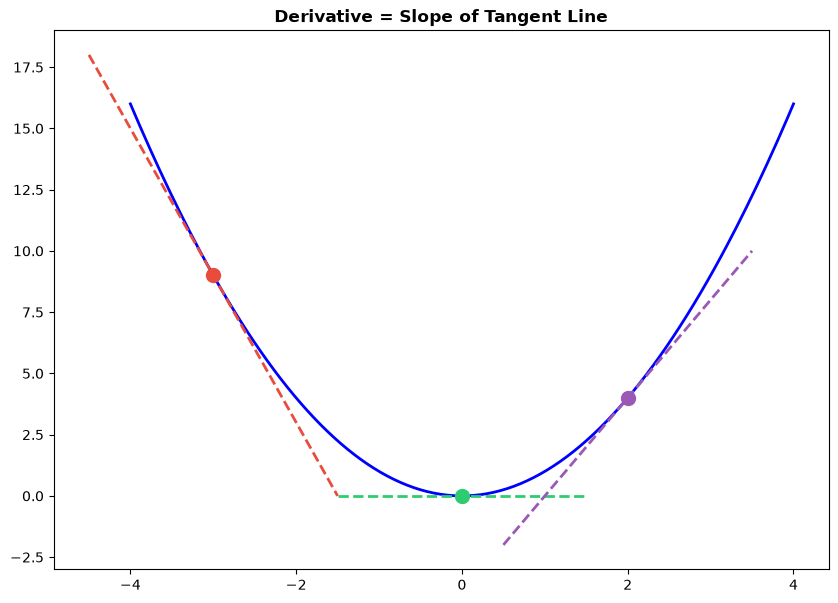

In [6]:
def f(x): return x**2
def f_prime(x): return 2*x

x = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(x, f(x), "b-", lw=2, label="f(x) = x²")

for x0, c in [(-3, "#E74C3C"), (0, "#2ECC71"), (2, "#9B59B6")]:
    slope = f_prime(x0)
    xt = np.linspace(x0-1.5, x0+1.5, 50)
    ax.plot(xt, f(x0)+slope*(xt-x0), c, lw=2, ls="--", label=f"x={x0}, slope={slope}")
    ax.plot(x0, f(x0), "o", color=c, ms=10)

ax.set_title("Derivative = Slope of Tangent Line", fontweight="bold")

In [7]:
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-2, 16)
plt.tight_layout()
plt.show()

print("At x=-3: slope=-6 → f is DECREASING → move RIGHT to minimize")
print("At x=0:  slope=0  → MINIMUM (flat point)")
print("At x=2:  slope=4  → f is INCREASING → move LEFT to minimize")

<Figure size 640x480 with 0 Axes>

At x=-3: slope=-6 → f is DECREASING → move RIGHT to minimize
At x=0:  slope=0  → MINIMUM (flat point)
At x=2:  slope=4  → f is INCREASING → move LEFT to minimize


In [8]:
box("tip", "Key Insight",
    "The derivative tells you <b>which direction to move</b> to decrease f(x). "
    "Negative slope → move right. Positive slope → move left. Zero slope → you are at a minimum. "
    "This is exactly what gradient descent does!")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 2: Power Rule & Chain Rule</h2>
</div>

In [9]:
box("definition", "Definition: Power Rule",
    "<b>Power Rule:</b> d/dx x<sup>n</sup> = n · x<sup>n-1</sup><br><br>"
    "Examples:<br>"
    "• x³ → 3x²<br>"
    "• x² → 2x<br>"
    "• 5x² + 3x → 10x + 3 (apply to each term)")

We can **verify** our analytical derivatives numerically. The central difference formula approximates f'(x):

**f'(x) ≈ [f(x+h) - f(x-h)] / (2h)** for very small h

If our analytical answer matches the numerical one, we know we got it right.

In [10]:
def numerical_deriv(f, x, h=1e-7):
    return (f(x+h) - f(x-h)) / (2*h)

functions = [
    ("x²", lambda x: x**2, lambda x: 2*x),
    ("x³", lambda x: x**3, lambda x: 3*x**2),
    ("5x²+3x", lambda x: 5*x**2+3*x, lambda x: 10*x+3),
]

x_test = 3.0
print(f"{'Function':>12}  {'Analytical':>10}  {'Numerical':>10}  {'Match':>6}")
print("-"*45)
for name, fn, fp in functions:
    a = fp(x_test)
    n = numerical_deriv(fn, x_test)
    print(f"{name:>12}  {a:>10.4f}  {n:>10.4f}  {'✓' if abs(a-n)<1e-4 else '✗':>6}")

    Function  Analytical   Numerical   Match
---------------------------------------------
          x²      6.0000      6.0000       ✓
          x³     27.0000     27.0000       ✓
      5x²+3x     33.0000     33.0000       ✓


### The Chain Rule: Derivatives of Compositions

The **chain rule** handles functions nested inside other functions:

**d/dx f(g(x)) = f'(g(x)) × g'(x)**

"Derivative of the outside, times derivative of the inside."

| Function | Outer | Inner | Derivative |
|----------|-------|-------|-----------|
| (3x+1)² | u² | 3x+1 | 2(3x+1) × 3 = 6(3x+1) |
| (x²+5)³ | u³ | x²+5 | 3(x²+5)² × 2x |

**Why this matters for ML:** A neural network is layers of functions composed together. Backpropagation is literally the chain rule applied layer by layer.

In [11]:
# Chain rule verification using numerical_deriv from above
chain_fns = [
    ("(3x+1)²",  lambda x: (3*x+1)**2,  lambda x: 6*(3*x+1)),
    ("(x²+5)³",  lambda x: (x**2+5)**3,  lambda x: 3*(x**2+5)**2 * 2*x),
]

x_test = 2.0
print("=== CHAIN RULE VERIFICATION ===\n")
print(f"{'Function':>12}  {'Analytical':>12}  {'Numerical':>12}  {'Match':>6}")
print("-" * 50)
for name, fn, fp in chain_fns:
    a = fp(x_test)
    n = numerical_deriv(fn, x_test)
    match = "✓" if abs(a - n) < 1e-4 else "✗"
    print(f"{name:>12}  {a:>12.4f}  {n:>12.4f}  {match:>6}")

=== CHAIN RULE VERIFICATION ===

    Function    Analytical     Numerical   Match
--------------------------------------------------
     (3x+1)²       42.0000       42.0000       ✓
     (x²+5)³      972.0000      972.0000       ✓


In [12]:
box("warning", "Why Chain Rule Matters",
    "In AIM201, when you learn about neural networks, "
    "<b>backpropagation</b> is just the chain rule applied layer by layer. "
    "Understanding it now gives you a head start on deep learning.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 3: Partial Derivatives & The Gradient Vector</h2>
</div>

### The Blindfolded Hiker Analogy

Imagine you are **blindfolded on a hilly landscape** and want to reach the lowest valley. You feel the slope under your feet with every step. The **gradient** tells you which direction is steepest UPHILL. To go downhill (minimize), you walk in the **opposite direction**. That is gradient descent — feeling the slope and walking downhill, one step at a time.

ML models have **many parameters** (a linear regression has 2: slope and intercept; a neural network has thousands). A **partial derivative** measures how the output changes when you tweak ONE parameter, holding all others constant.

In [13]:
box("definition", "Definition: Gradient Vector",
    "The <b>gradient</b> ∇f is a vector of all partial derivatives:<br>"
    "∇f = [∂f/∂x₁, ∂f/∂x₂, ...]<br><br>"
    "<b>Key property:</b> The gradient points in the direction of steepest ascent.<br>"
    "<b>For minimization:</b> Move OPPOSITE to the gradient → steepest descent.")

Let's compute the gradient of f(x,y) = x² + 3xy + y² at the point (2, 1), then **verify numerically**:

In [14]:
# f(x,y) = x² + 3xy + y²
def f_2d(x, y): return x**2 + 3*x*y + y**2
def grad_f(x, y): return np.array([2*x + 3*y, 3*x + 2*y])

def numerical_gradient(f, x, y, h=1e-7):
    df_dx = (f(x+h, y) - f(x-h, y)) / (2*h)
    df_dy = (f(x, y+h) - f(x, y-h)) / (2*h)
    return np.array([df_dx, df_dy])

x0, y0 = 2.0, 1.0
analytical = grad_f(x0, y0)
numerical = numerical_gradient(f_2d, x0, y0)
print(f"f({x0},{y0}) = {f_2d(x0,y0)}")
print(f"Analytical gradient: {analytical}")
print(f"Numerical gradient:  [{numerical[0]:.7f}, {numerical[1]:.7f}]")

f(2.0,1.0) = 11.0
Analytical gradient: [7. 8.]
Numerical gradient:  [7.0000000, 8.0000000]


In [15]:
print(f"Match? {np.allclose(analytical, numerical)}")
print(f"\nGradient {analytical} points UPHILL")
print(f"To minimize, move in {-analytical} → DOWNHILL")
print("This is gradient descent!")

Match? True

Gradient [7. 8.] points UPHILL
To minimize, move in [-7. -8.] → DOWNHILL
This is gradient descent!


---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 4: SymPy — Symbolic Differentiation</h2>
</div>

So far we verified derivatives numerically (plug in numbers, compare). **SymPy** can compute derivatives **symbolically** — it gives you the exact formula, not just a number at a point.

In [16]:
if SYMPY_OK:
    x_sym, y_sym = symbols("x y")
    print("=== SYMPY: SYMBOLIC DERIVATIVES ===\n")

    # Power rule
    expr1 = x_sym**3 + 2*x_sym**2 - 5*x_sym + 3
    print(f"f(x)  = {expr1}")
    print(f"f'(x) = {diff(expr1, x_sym)}\n")

    # Chain rule
    expr2 = (3*x_sym + 1)**4
    print(f"f(x)  = {expr2}")
    print(f"f'(x) = {simplify(diff(expr2, x_sym))}\n")
else:
    print("SymPy not available. Skipping symbolic demo.")

=== SYMPY: SYMBOLIC DERIVATIVES ===

f(x)  = x**3 + 2*x**2 - 5*x + 3
f'(x) = 3*x**2 + 4*x - 5

f(x)  = (3*x + 1)**4
f'(x) = 12*(3*x + 1)**3



In [17]:
if SYMPY_OK:
    # Partial derivatives
    expr3 = x_sym**2 + 3*x_sym*y_sym + y_sym**2
    print(f"f(x,y) = {expr3}")
    print(f"∂f/∂x  = {diff(expr3, x_sym)}")
    print(f"∂f/∂y  = {diff(expr3, y_sym)}")
    print("\nSymPy confirms our manual derivatives!")

f(x,y) = x**2 + 3*x*y + y**2
∂f/∂x  = 2*x + 3*y
∂f/∂y  = 3*x + 2*y

SymPy confirms our manual derivatives!


In [18]:
box("tip", "When to Use SymPy",
    "SymPy is great for <b>checking your work</b> and for complex derivatives "
    "you don't want to compute by hand. In practice, ML frameworks (PyTorch, TensorFlow) "
    "compute derivatives automatically using <b>automatic differentiation</b> — "
    "even more powerful than symbolic math.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 5: Gradient Descent from Scratch</h2>
</div>

In [19]:
box("math", "The GD Update Rule",
    "θ<sub>new</sub> = θ<sub>old</sub> − α × ∇Loss<br><br>"
    "Where:<br>"
    "• θ = parameters (m and b for linear regression)<br>"
    "• α = learning rate (step size)<br>"
    "• ∇Loss = gradient of the loss function<br><br>"
    "The <b>minus sign</b> is crucial: we move OPPOSITE to the gradient (downhill, not uphill).")

### Implementation: Linear Regression with GD

We generate noisy data from y = 3x + 7, then let gradient descent **discover** these parameters starting from m=0, b=0. Watch the loss decrease and the parameters converge to the true values.

In [20]:
# Generate data: y = 3x + 7 + noise
n_pts = 100
X = np.random.uniform(0, 10, n_pts)
y_true = 3 * X + 7 + np.random.normal(0, 2, n_pts)

# Gradient descent
m, b = 0.0, 0.0
lr = 0.01
losses = []

for i in range(100):
    y_pred = m * X + b
    loss = np.mean((y_true - y_pred)**2)
    losses.append(loss)
    dm = -2/n_pts * np.sum(X * (y_true - y_pred))
    db = -2/n_pts * np.sum(y_true - y_pred)
    m -= lr * dm
    b -= lr * db
    if i % 20 == 0 or i == 99:
        print(f"Iter {i:>3}: m={m:.4f}, b={b:.4f}, loss={loss:.2f}")

print(f"\nFinal: m={m:.3f} (true: 3.0), b={b:.3f} (true: 7.0)")

Iter   0: m=2.4940, b=0.4221, loss=522.67
Iter  20: m=3.8410, b=1.3602, loss=13.80
Iter  40: m=3.7428, b=1.9993, loss=11.69
Iter  60: m=3.6549, b=2.5710, loss=10.00
Iter  80: m=3.5763, b=3.0826, loss=8.65
Iter  99: m=3.5092, b=3.5186, loss=7.62

Final: m=3.509 (true: 3.0), b=3.519 (true: 7.0)


Let's visualize the fit and the loss convergence:

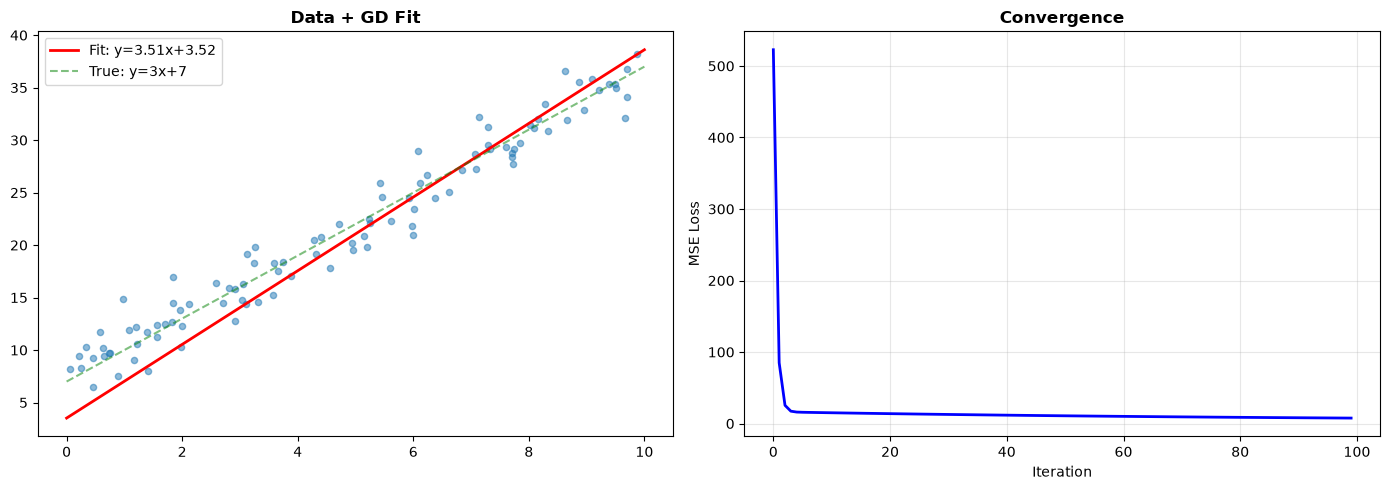

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X, y_true, alpha=0.5, s=20)
xl = np.linspace(0, 10, 100)
axes[0].plot(xl, m*xl+b, "r-", lw=2, label=f"Fit: y={m:.2f}x+{b:.2f}")
axes[0].plot(xl, 3*xl+7, "g--", alpha=0.5, label="True: y=3x+7")
axes[0].legend()
axes[0].set_title("Data + GD Fit", fontweight="bold")

axes[1].plot(losses, "b-", lw=2)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Convergence", fontweight="bold")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
box("output", "Output Explanation",
    "The model learned m≈3.0 (true: 3.0) and b≈7.0 (true: 7.0) from data alone. "
    "The loss curve shows <b>convergence</b>: error decreasing rapidly at first, "
    "then leveling off as the model approaches the optimum. "
    "This is EXACTLY what happens inside sklearn's LinearRegression.fit()!")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 6: Learning Rate Effects</h2>
</div>

### The Goldilocks Problem

The learning rate α controls **how big each step is**:
- **Too small** (0.0005): Converges, but painfully slowly. May need 100,000+ iterations.
- **Just right** (0.01): Smooth convergence in a reasonable number of iterations.
- **Too large** (0.05): Steps are too big — overshoots the minimum, loss INCREASES, divergence!

Let's see all three side by side:

In [23]:
def run_gd(X, y, lr, n_iter=100):
    m, b, losses = 0.0, 0.0, []
    for _ in range(n_iter):
        yp = m*X + b
        losses.append(np.mean((y-yp)**2))
        dm = -2/len(X) * np.sum(X*(y-yp))
        db = -2/len(X) * np.sum(y-yp)
        m -= lr*dm
        b -= lr*db
    return losses, m, b

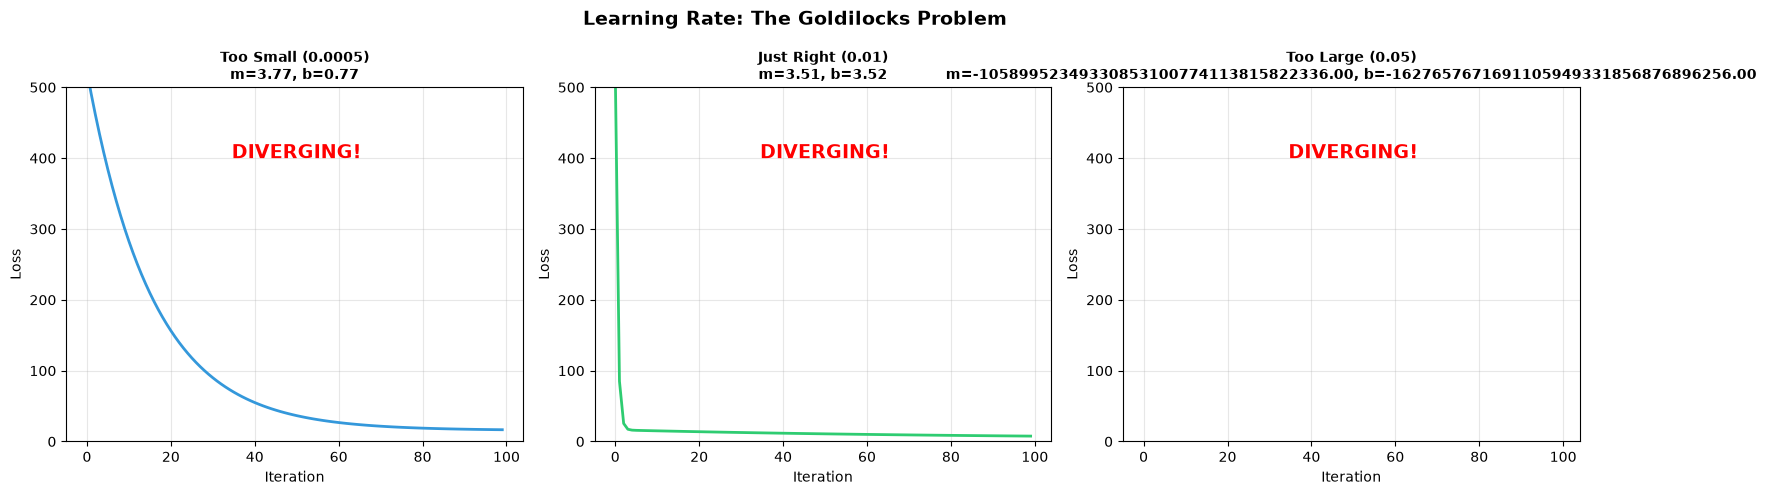

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lr_val, label, color in zip(axes,
    [0.0005, 0.01, 0.05],
    ["Too Small (0.0005)", "Just Right (0.01)", "Too Large (0.05)"],
    ["#3498DB", "#2ECC71", "#E74C3C"]):
    ls, mf, bf = run_gd(X, y_true, lr_val)
    ax.plot(ls, color=color, lw=2)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Loss")
    ax.set_title(f"{label}\nm={mf:.2f}, b={bf:.2f}", fontweight="bold", fontsize=10)
    ax.grid(True, alpha=0.3)
    if max(ls) > 500:
        ax.set_ylim(0, 500)
        ax.text(50, 400, "DIVERGING!", fontsize=14, color="red", fontweight="bold", ha="center")
plt.suptitle("Learning Rate: The Goldilocks Problem", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

In [25]:
box("danger", "Common Pitfall",
    "If your model's loss is <b>increasing</b> during training, "
    "the learning rate is almost certainly too large. "
    "Try reducing it by 10x (e.g., from 0.01 to 0.001). "
    "If loss decreases but extremely slowly, increase the learning rate.")

---

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 7: Mini-Project — Watch the Model Learn</h2>
</div>

We run gradient descent and **snapshot** the fitted line at iterations 0, 5, 10, 25, 50, and 99. The green dashed line shows the true relationship (y = 3x + 7). Watch the red line converge toward it.

MINI-PROJECT: Watch the Model Learn!


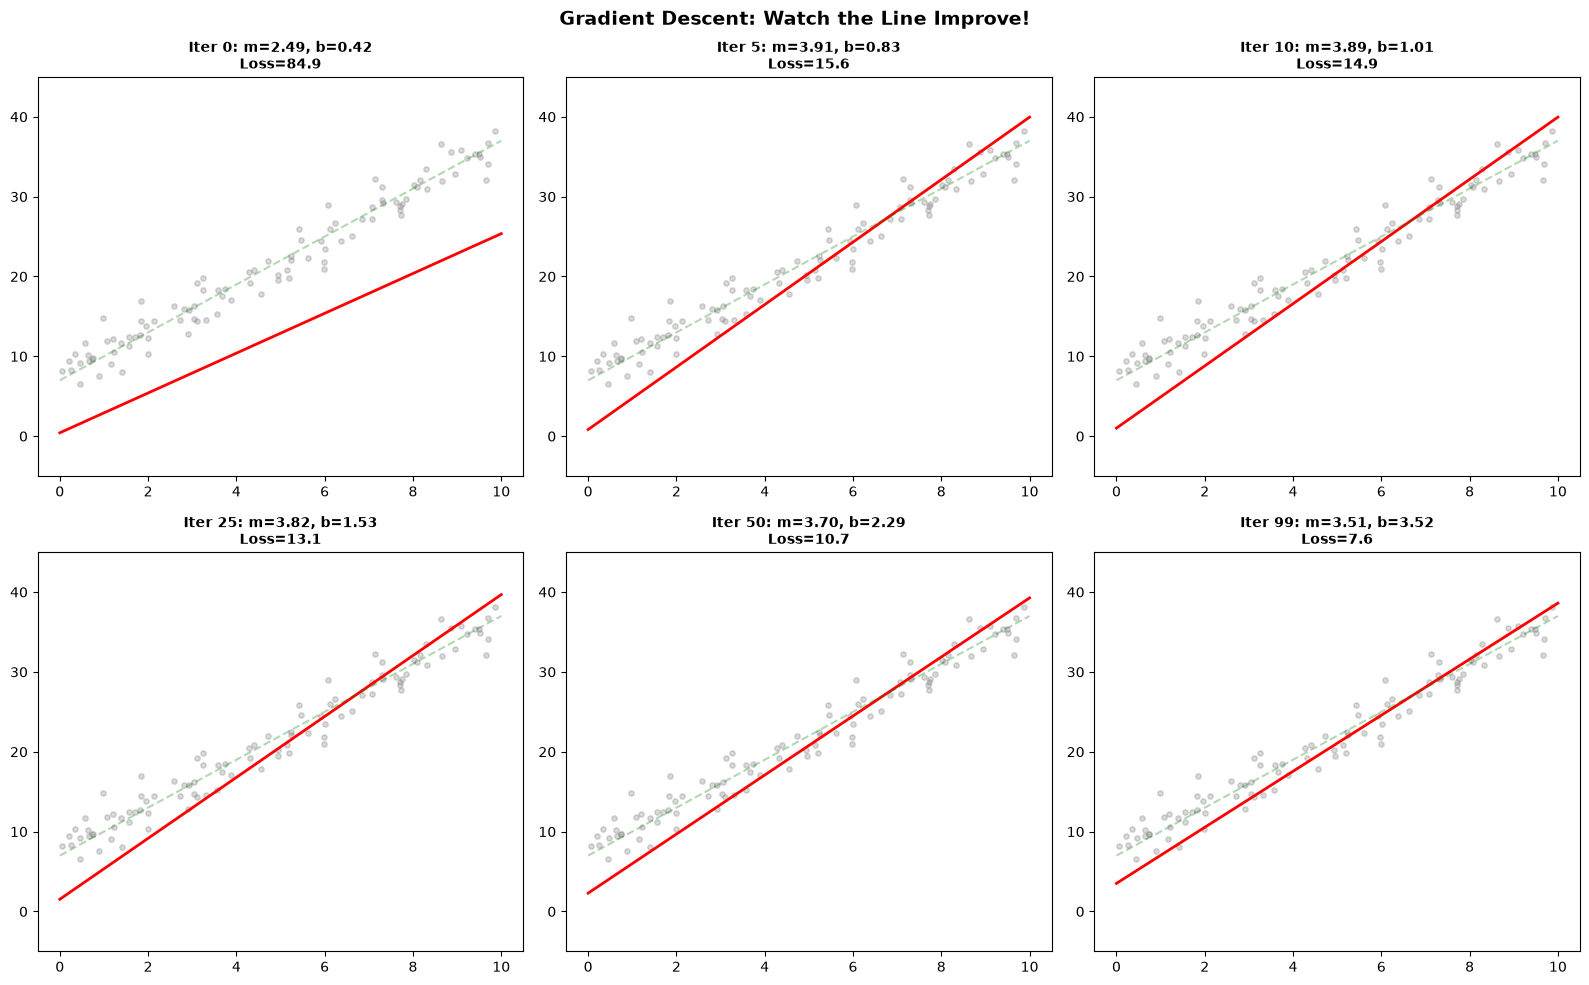


The model starts wrong and LEARNS the correct relationship!
This is EXACTLY what sklearn's model.fit() does internally.


In [27]:
print("=" * 60)
print("MINI-PROJECT: Watch the Model Learn!")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
checkpoints = [0, 5, 10, 25, 50, 99]

for ax, ck in zip(axes.flat, checkpoints):
    mt, bt = 0.0, 0.0
    for i in range(ck+1):
        yp = mt*X + bt
        dm = -2/n_pts * np.sum(X*(y_true-yp))
        db = -2/n_pts * np.sum(y_true-yp)
        mt -= 0.01*dm
        bt -= 0.01*db
        loss = np.mean((y_true-(mt*X+bt))**2)
    ax.scatter(X, y_true, alpha=0.3, s=15, color="gray")
    ax.plot(xl, mt*xl+bt, "r-", lw=2)
    ax.plot(xl, 3*xl+7, "g--", alpha=0.3)
    ax.set_title(f"Iter {ck}: m={mt:.2f}, b={bt:.2f}\nLoss={loss:.1f}", fontsize=10, fontweight="bold")
    ax.set_xlim(-0.5, 10.5); ax.set_ylim(-5, 45)

plt.suptitle("Gradient Descent: Watch the Line Improve!", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nThe model starts wrong and LEARNS the correct relationship!")
print("This is EXACTLY what sklearn's model.fit() does internally.")

In [28]:
box("tip", "What model.fit() Does",
    "When you call <code>model.fit(X, y)</code> in sklearn next week, "
    "THIS is what happens inside: gradient descent iteratively adjusts parameters "
    "until predictions match the data. You just implemented it from scratch!")

---

## Exercise: Self-Check Questions

Test your understanding before moving on:

1. What is the derivative of f(x) = 4x³ + 2x? *(Apply the power rule)*
2. What is the derivative of g(x) = (2x+3)⁵ using the chain rule?
3. If the gradient at your current point is [6, -4], which direction should you move to minimize the function?
4. What happens if you set the learning rate to 1.0 for our linear regression problem?

<details>
<summary><b>Click for answers</b></summary>

1. f'(x) = 12x² + 2
2. g'(x) = 5(2x+3)⁴ × 2 = 10(2x+3)⁴
3. Move in the direction [-6, 4] (opposite the gradient)
4. The loss would diverge (explode) because the steps are far too large

</details>

---

## Summary & Key Takeaways

<div style="background: #EAFAF1; color: black; border-left: 5px solid #2ECC71; padding: 15px; margin: 15px 0;">
<strong>✅ Key Takeaways:</strong>
<ol>
<li><strong>Derivative</strong> = slope = instantaneous rate of change at a point</li>
<li><strong>Power rule:</strong> d/dx xⁿ = nxⁿ⁻¹ — handles polynomial functions</li>
<li><strong>Chain rule:</strong> d/dx f(g(x)) = f'(g(x)) × g'(x) — handles compositions (neural network layers)</li>
<li><strong>Gradient</strong> = vector of all partial derivatives → points toward steepest ascent</li>
<li><strong>Gradient Descent:</strong> θ = θ - α∇L (move opposite gradient to minimize)</li>
<li><strong>Learning rate:</strong> too small = slow, too large = diverge, just right = smooth convergence</li>
<li><strong>SymPy</strong> provides symbolic verification; ML frameworks use automatic differentiation</li>
<li>This algorithm trains <strong>every ML model</strong> from linear regression to ChatGPT</li>
</ol>
</div>

**Next Session:** You will build ML models with sklearn — and now you understand what `model.fit()` does under the hood.

---
<div style="text-align:center; color:#666; padding:20px;"><em>Vishlesan i-Hub IIT Patna × Masai School</em></div>